#### 使用linprog函数求解

$$result = linprog(c,A_{ub},b_{ub},A_{eq},b_{eq},bounds,method)$$
$\min_{x} cx_i, $
<br>
$
s.t. = \begin{cases}
                A_{ub} \cdot x_i \leq b_{ub}, \\
                A_{eq} \cdot x_i = b_{eq}, \\
                x_i \in bounds. \\
        \end{cases}
$
<br>
<div>
    <ul>
    <li> $bounds$ &mdash&mdash $n \times 2$范围矩阵 None表示无穷, 默认为$[0,None]$ </li>     
    <li> $method$ &mdash&mdash 调用的求解方法,默认为$higns$ </li>
    <li> $result$有多个参数 常用有$x$为解向量, $fun$为函数最小值,$nit$为迭代次数等 </li>
    </ul>
</div>



## 例 
$$ \min   -y = -20x_1 - 30x_2 - 45x_3 $$
$$ s.t. = \begin{cases}
            4x_1 + 8x_2 + 15x_3 \leq 100, \\
            x_1 + x_2 + x_3 \leq 20, \\
            x_1,x_2,x_3 \geq 0.
          \end{cases}
$$ 
## 可化为
$$
    \begin{cases}
    c = \left[-20,-30,-45\right] \\
    A_{ub} = \left[ 
                    \begin{matrix}
                    4, & 8, & 15 \\
                    1, & 1, & 1 
                    \end{matrix}
             \right] \\
    B_{ub} = \left[ 100,20 \right] \\
    bounds = \left[
                    \begin{matrix}
                    0, & None \\
                    0, & None \\
                    0, & None
                    \end{matrix}
              \right]
    \end{cases}
$$

In [1]:
import numpy as np
from scipy.optimize import linprog

c = [-20,-30,-45]
A_ub = [[4,8,15],
        [1,1,1]]
b_ub = [100,20]
bounds = [[0,None], # 从题目可隐式挖掘出这个bounds,但是linprog默认就是[0,None]
          [0,None],
          [0,None],]

res = linprog(c,A_ub,b_ub,method = "highs")

print(res)
print("解向量为: ",res.x)
print("目标函数的解为: ",-res.fun)


        message: Optimization terminated successfully. (HiGHS Status 7: Optimal)
        success: True
         status: 0
            fun: -450.0
              x: [ 1.500e+01  5.000e+00  0.000e+00]
            nit: 2
          lower:  residual: [ 1.500e+01  5.000e+00  0.000e+00]
                 marginals: [ 0.000e+00  0.000e+00  2.500e+00]
          upper:  residual: [       inf        inf        inf]
                 marginals: [ 0.000e+00  0.000e+00  0.000e+00]
          eqlin:  residual: []
                 marginals: []
        ineqlin:  residual: [ 0.000e+00  0.000e+00]
                 marginals: [-2.500e+00 -1.000e+01]
 mip_node_count: 0
 mip_dual_bound: 0.0
        mip_gap: 0.0
解向量为:  [15.  5.  0.]
目标函数的解为:  450.0


## 例题/1998年国赛A题)
市场上有$n$种资产(如股票、债券、……)$s_i(i=1,2,…,n)$供投资者选择，某公司有数额为$M$的
一笔相当大的资金可用作一个时期的投资。公司财务分析人员对这$n$种资产进行了评估，估算出在
这一时期内购买资产$s_i$,的平均收益率为$r_i$，并预测出购买$s_i$,的风险损失率为$q_i$。考虑到投资越分散,
总的风险越小，公司确定，当用这笔资金购买若干种资产时，总体风险可用所投资的$s_i$中最大的一
个风险来度量。购买$s_i$要付交易费，费率为$p_i$，并且当购买额不超过给定值$u_i$时，交易费按购买$u_i$计算(不买当然无须付费)。另外，假定同期银行存款利率是r(r=5%)，且既无交易费又无风险,已知n=4时的相关数据如表所示。

![相关数据](规划-线性规划求解01.png)

## 简化模型 (风险最低，收益最高 => 在一定的可接受风险$a$内的收益最高)
<br>
## 根据表格数据可以得出
$ \min -f = -[0.05,0.27,0.19,0.185,0.185] \cdot [x_0,x_1,x_2,x_3,x_4]^{\top} $
<br>
<br>
$ s.t. = \begin{cases}
            x_0 + 1.01x_1 + 1.02x_2 + 1.045x_3 + 1.065x_4 = M, \\
            0.025x1 \leq aM, \\
            0.015x_2 \leq aM, \\
            0.055x_3 \leq aM, \\
            0.026x_4 \leq aM, \\
            x_i \geq 0 (i = 0,1,\ldots,4)
         \end{cases}
$

#### $\cdot$ 由于$M$题目并未给出,估可任意取，这里可取$M = 1$万元
#### $\cdot$ 同时a是为了消解多目标引入的可接受风险度,考虑到不同的投资者有不同的风险度  
#### 这里可以以步长 $\Delta a = 0.001$进行循环搜索至$a = 5\%$ (一个合适的低风险方案)

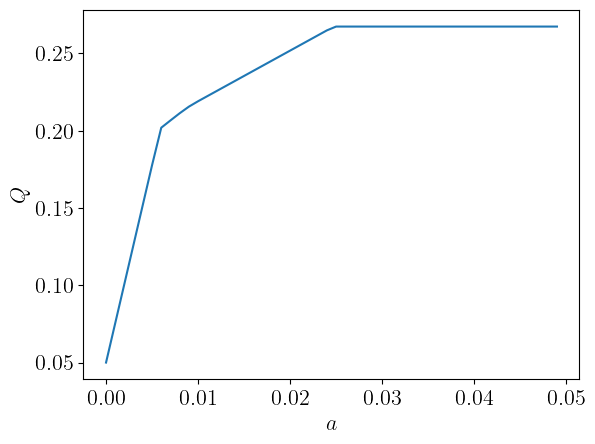

In [5]:
import matplotlib.pyplot as plt
from numpy import ones,diag,c_,zeros
from scipy.optimize import linprog

plt.rc("text", usetex=True) # 设置绘图格式使其支持LaTex文本和字体的大小
plt.rc("font", size = 16)

c = [-0.05,-0.27,-0.19,-0.185,-0.185]

# c_用于在列方向上拼接数组 zeros用于创建数组,diag创建对角阵
A_ub = c_[zeros(4),diag([0.025,0.015,0.055,0.026])]

A_eq = [[1,1.01,1.02,1.045,1.065]]
B_eq = [1]

a = 0
# 建立两轴列表，为画图使用
x_axis = []
y_axis = []

while a < 0.05:
    B_ub = ones(4) * a
    
    res = linprog(c,A_ub,B_ub,A_eq,B_eq,method="highs")
    
    x_axis.append(a) # 存入可接受风险a
    y_axis.append(-res.fun) # 存入最优解
    
    a += 0.001


plt.plot(x_axis,y_axis) # 使用plot画图,'r*' 使用红色*号标记数据点    

plt.xlabel('$a$')
plt.ylabel('$Q$',rotation = 90)

plt.show()
